In [2]:
import pandas as pd
import numpy as np
import math
from datetime import timedelta
import itertools
from shapely.geometry import shape, Point
import random
from typing import List, Tuple, Optional, Dict
from dataclasses import dataclass
import os
import matplotlib.pyplot as plt
os.environ["OMP_NUM_THREADS"] = "1"
print("OMP_NUM_THREADS =", os.environ["OMP_NUM_THREADS"])

from sklearn.cluster import KMeans



OMP_NUM_THREADS = 1


# Defining functions to be used

In [3]:
@dataclass
class Order:
    """
    Represents a customer order with spatial, temporal, and logistic attributes.

    Attributes:
    -----------
    order_id : int
        Unique identifier of the order.
    order_latitude : float
        Latitude of the order location.
    order_longitude : float
        Longitude of the order location.
    ordered_at_brt : pd.Timestamp
        Timestamp when the order was placed.
    order_weight : float
        Weight of the order in kilograms.
    sla_hours : int
        SLA in hours from order to expected delivery.
    sla_max_delivery_time_brt : pd.Timestamp
        Deadline for the delivery according to the SLA.
    """

    order_id: int
    order_latitude: float
    order_longitude: float
    ordered_at_brt: pd.Timestamp
    order_weight: float
    sla_hours: int
    sla_max_delivery_time_brt: pd.Timestamp

    @classmethod
    def from_row(cls, row: pd.Series) -> "Order":
        """
        Instantiates an Order from a row of a DataFrame.

        Parameters:
        -----------
        row : pd.Series
            Row containing the order information.

        Returns:
        --------
        Order
            The instantiated Order object.
        """
        return cls(
            order_id=int(row["order_id"]),
            order_latitude=row["order_latitude"],
            order_longitude=row["order_longitude"],
            ordered_at_brt=pd.to_datetime(row["ordered_at_brt"]),
            order_weight=row["order_weight"],
            sla_hours=int(row["sla_hours"]),
            sla_max_delivery_time_brt=pd.to_datetime(row["sla_max_delivery_time_brt"]),
        )

    def to_dict(self) -> Dict:
        """
        Converts the Order instance into a dictionary.

        Returns:
        --------
        dict
            Dictionary representation of the Order object.
        """
        return {
            "order_id": self.order_id,
            "order_latitude": self.order_latitude,
            "order_longitude": self.order_longitude,
            "ordered_at_brt": self.ordered_at_brt,
            "order_weight": self.order_weight,
            "sla_hours": self.sla_hours,
            "sla_max_delivery_time_brt": self.sla_max_delivery_time_brt,
        }


def load_city_orders_coordinates(
    orders_path: str,
    customers_path: str,
    geolocation_path: str,
    chosen_city: str,
    chosen_state: str
) -> pd.DataFrame:
    """
    Loads and merges orders and customer geolocations for a given city and state.

    Parameters:
    -----------
    orders_path : str
        File path to the orders CSV.
    customers_path : str
        File path to the customers CSV.
    geolocation_path : str
        File path to the geolocation CSV.
    chosen_city : str
        City name to filter customers.
    chosen_state : str
        State abbreviation to filter customers.

    Returns:
    --------
    pd.DataFrame
        Merged DataFrame with order_id, latitude, and longitude.
    """
    orders = pd.read_csv(orders_path)
    customers = pd.read_csv(customers_path)
    geolocation = pd.read_csv(geolocation_path)

    customers_city = customers[
        (customers.customer_city == chosen_city) &
        (customers.customer_state == chosen_state)
    ]

    geolocation_refined = (
        geolocation
        .groupby('geolocation_zip_code_prefix')
        .agg(
            order_latitude=('geolocation_lat', 'max'),
            order_longitude=('geolocation_lng', 'max')
        )
        .reset_index()
    )

    merged_df = (
        pd.merge(
            orders[['order_id', 'customer_id']],
            customers_city[['customer_id', 'customer_zip_code_prefix']],
            on='customer_id'
        )
        .merge(
            geolocation_refined,
            left_on='customer_zip_code_prefix',
            right_on='geolocation_zip_code_prefix'
        )
        .drop(columns=['customer_id', 'customer_zip_code_prefix', 'geolocation_zip_code_prefix'])
    )

    return merged_df


import pandas as pd

def load_and_filter_delivery_data(orders_path, deliveries_path, drivers_path):
    """
    Loads and filters delivery data using business logic criteria.

    This function performs:
    - Loading CSV files for orders, deliveries, and drivers.
    - Filtering orders with status 'FINISHED' and deliveries with status 'DELIVERED'.
    - Dropping rows with null values in key timestamp columns.
    - Merging the datasets on appropriate keys.
    - Parsing timestamps to datetime.
    - Computing time-to-dispatch and time-in-route (in minutes).
    - Filtering rows based on:
        - Positive delivery times
        - Reasonable dispatch time (1–30 min)
        - Valid delivery distance (>100m)
        - Driver modal equal to 'MOTOBOY'
        - Reasonable average delivery speed for urban distances (3–60 km/h)

    Parameters
    ----------
    orders_path : str
        Path to the orders CSV file.
    deliveries_path : str
        Path to the deliveries CSV file.
    drivers_path : str
        Path to the drivers CSV file.

    Returns
    -------
    pd.DataFrame
        Filtered and enriched delivery dataset.
    """
    
    # Load CSVs
    orders = pd.read_csv(orders_path)
    deliveries = pd.read_csv(deliveries_path)
    drivers = pd.read_csv(drivers_path)

    # Filter orders and deliveries
    orders = orders[orders['order_status'] == 'FINISHED']
    deliveries = deliveries[deliveries['delivery_status'] == 'DELIVERED'].drop_duplicates(subset='delivery_order_id')
    orders = orders.dropna(subset=['order_moment_created', 'order_moment_ready', 'order_moment_collected', 'order_moment_delivering'])

    # Merge data
    df = (
        orders[['order_id','delivery_order_id','order_moment_created', 'order_moment_accepted',
                'order_moment_ready', 'order_moment_collected', 'order_moment_in_expedition',
                'order_moment_delivering','order_moment_finished']]
        .merge(deliveries, on='delivery_order_id')
        .merge(drivers, on='driver_id')
    )

    # Convert timestamps
    datetime_cols = ['order_moment_accepted', 'order_moment_delivering', 'order_moment_finished']
    for col in datetime_cols:
        df[col] = pd.to_datetime(df[col], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')

    # Compute time features in minutes
    df['time_to_dispatch'] = (df['order_moment_delivering'] - df['order_moment_accepted']).dt.total_seconds() / 60
    df['time_in_route'] = (df['order_moment_finished'] - df['order_moment_delivering']).dt.total_seconds() / 60

    # Filter based on business logic
    df = df[
        (df['time_to_dispatch'] > 0) &
        (df['time_in_route'] > 0) &
        (df['delivery_distance_meters'] > 500) &
        (df['driver_modal'] == 'MOTOBOY')
    ]

    # Estimate delivery speed (km/h)
    df['km_hour'] = (df['delivery_distance_meters'] / df['time_in_route']) * 0.06

    # Final filters
    df = df[
        (df['km_hour'] > 3) & (df['km_hour'] < 60) &
        (df['time_to_dispatch'] > 1) & (df['time_to_dispatch'] < 30)
    ]

    return df


class SyntheticOrderGenerator:
    """
    A class to generate synthetic order data including timestamps and order metadata
    based on Poisson arrival processes and real coordinates.
    """

    def __init__(
        self,
        num_samples: int,
        avg_interval_minutes: float,
        coordinates_df: pd.DataFrame,
        weight_mean: float = 5,
        weight_stddev: float = 2,
        weight_bounds: Tuple[float, float] = (0.01, 20),
        sla_choices: List[int] = [1, 2],
        sla_probs: List[float] = [0.5, 0.5],
        start_time: str = "2024-04-01 00:00:00",
        seed: int = 1
    ):
        """
        Initializes the synthetic order generator with configuration.

        Parameters:
        -----------
        num_samples : int
            Number of orders to generate.
        avg_interval_minutes : float
            Desired average interval between order arrivals.
        coordinates_df : pd.DataFrame
            DataFrame with columns 'order_latitude' and 'order_longitude'.
        weight_mean : float
            Mean order weight.
        weight_stddev : float
            Standard deviation of order weight.
        weight_bounds : Tuple[float, float]
            Minimum and maximum weight values.
        sla_choices : List[int]
            SLA options in hours.
        sla_probs : List[float]
            Probabilities corresponding to SLA options.
        start_time : str
            Start timestamp for order generation.
        seed : int
            Random seed for reproducibility.
        """
        self.num_samples = num_samples
        self.avg_interval_minutes = avg_interval_minutes
        self.coordinates_df = coordinates_df
        self.weight_mean = weight_mean
        self.weight_stddev = weight_stddev
        self.weight_bounds = weight_bounds
        self.sla_choices = sla_choices
        self.sla_probs = sla_probs
        self.start_time = start_time
        self.seed = seed
        np.random.seed(seed)

    def generate_timestamps(self) -> List[pd.Timestamp]:
        """
        Generates order arrival timestamps using an exponential distribution.

        Returns:
        --------
        List[pd.Timestamp]
            List of synthetic order timestamps.
        """
        rate_lambda = 1 / self.avg_interval_minutes
        intervals = np.random.exponential(scale=1 / rate_lambda, size=self.num_samples)
        base_time = pd.Timestamp(self.start_time)

        timestamps = [base_time]
        for interval in intervals:
            timestamps.append(timestamps[-1] + pd.Timedelta(minutes=interval))

        return timestamps[1:]  # Remove initial time

    def generate_orders(self) -> pd.DataFrame:
        """
        Generates synthetic order data using the generated timestamps and coordinates.

        Returns:
        --------
        pd.DataFrame
            DataFrame containing synthetic orders with timestamps, coordinates, weight, and SLA.
        """
        timestamps = self.generate_timestamps()
        sampled_coords = self.coordinates_df.sample(n=self.num_samples, replace=True).reset_index(drop=True)
        weights = np.random.normal(self.weight_mean, self.weight_stddev, self.num_samples)
        weights = np.clip(weights, self.weight_bounds[0], self.weight_bounds[1])
        sla_hours = np.random.choice(self.sla_choices, size=self.num_samples, p=self.sla_probs)

        df = pd.DataFrame({
            "order_id": range(1, self.num_samples + 1),
            "order_longitude": sampled_coords['order_longitude'],
            "order_latitude": sampled_coords['order_latitude'],
            "ordered_at_brt": timestamps,
            "sla_hours": sla_hours,
            "order_weight": weights
        })

        df["sla_max_delivery_time_brt"] = df["ordered_at_brt"] + pd.to_timedelta(df["sla_hours"], unit="h")
        return df

    def generate(self) -> pd.DataFrame:
        """
        Wrapper method to generate the full synthetic order dataset.

        Returns:
        --------
        pd.DataFrame
            Full synthetic order DataFrame.
        """
        return self.generate_orders()

class HubLocations:
    """
    Handles hub coverage evaluation and selection of optimal hub positions using KMeans.

    Parameters:
    -----------
    coordinates : np.ndarray
        Array of [lat, lon] coordinates to cluster.
    k_range : range
        Range of K (number of hubs) to evaluate.
    max_distance_km : float
        Max distance for a point to be considered covered by a hub.
    seed : int
        Random seed for reproducibility.
    """
    def __init__(
        self,
        coordinates: np.ndarray,
        k_range: range,
        max_distance_km: float = 3.0,
        seed: int = 1
    ):
        self.coordinates = coordinates
        self.k_range = k_range
        self.max_distance_km = max_distance_km
        self.seed = seed
        self.coverage_df = None
        self.optimal_k = None
        self.hubs = None

    def evaluate_coverage(self) -> pd.DataFrame:
        """
        Evaluates coverage % for each K in k_range based on max_distance_km.

        Returns:
        --------
        pd.DataFrame
            DataFrame with columns ["num_hubs", "percent_covered"]
        """
        np.random.seed(self.seed)
        results = []

        for k in self.k_range:
            kmeans = KMeans(n_clusters=k, random_state=self.seed).fit(self.coordinates)
            centers = kmeans.cluster_centers_
            labels = kmeans.predict(self.coordinates)

            distances = [
                haversine(self.coordinates[i], centers[labels[i]])
                for i in range(len(self.coordinates))
            ]
            covered = np.array(distances) <= self.max_distance_km
            results.append((k, covered.mean() * 100))

        self.coverage_df = pd.DataFrame(results, columns=["num_hubs", "percent_covered"])
        return self.coverage_df

    def select_optimal_hubs(self, target_coverage: float) -> Tuple[int, pd.DataFrame]:
        """
        Finds the minimum K such that at least target_coverage % of points are covered.

        Returns:
        --------
        Tuple[int, pd.DataFrame]
            Optimal K and a DataFrame of hub coordinates.
        """
        if self.coverage_df is None:
            self.evaluate_coverage()

        filtered = self.coverage_df[self.coverage_df["percent_covered"] >= target_coverage]
        if filtered.empty:
            raise ValueError("No K satisfies the desired coverage.")

        self.optimal_k = int(filtered["num_hubs"].iloc[0])
        kmeans = KMeans(n_clusters=self.optimal_k, random_state=self.seed).fit(self.coordinates)
        centers = kmeans.cluster_centers_

        hubs = pd.DataFrame(centers, columns=["hub_latitude", "hub_longitude"])
        hubs["hub_id"] = range(1, len(hubs) + 1)
        self.hubs = hubs[["hub_id", "hub_latitude", "hub_longitude"]]

        return self.optimal_k, self.hubs

    def plot_coverage_curve(self, target_coverage: float = 95.0) -> None:
        """
        Plots the % coverage for each K tested, with a target line.

        Parameters:
        -----------
        target_coverage : float
            Target percentage to highlight on the plot.
        """
        if self.coverage_df is None:
            self.evaluate_coverage()

        plt.figure(figsize=(10, 5))
        plt.plot(self.coverage_df["num_hubs"], self.coverage_df["percent_covered"], marker='o')
        plt.axhline(y=target_coverage, color='r', linestyle='--', label=f"Target: {target_coverage}%")
        plt.xlabel("Number of Hubs (K)")
        plt.ylabel("Coverage (%)")
        plt.title("Hub Coverage vs Number of Hubs")
        plt.legend()
        plt.grid(True)
        plt.show()

# -------------------------------
# Distance-related utilities
# -------------------------------

def calculate_distance(row):
    """
    Calculates the Haversine distance (in kilometers) between an order and a hub.

    Parameters:
    -----------
    row : pd.Series
        A row with 'order_latitude', 'order_longitude', 'hub_latitude', 'hub_longitude'.

    Returns:
    --------
    float
        Distance in kilometers.
    """
    order_coords = (row['order_latitude'], row['order_longitude'])
    hub_coords = (row['hub_latitude'], row['hub_longitude'])
    return haversine(order_coords, hub_coords)


# -------------------------------
# Route assignment strategies
# -------------------------------

def assign_route_id_moving_window(df, hub_col, max_adensing_minutes, max_orders_per_route, max_weight_per_route):
    """
    Assigns route IDs using a moving window strategy, creating new routes when time,
    order count, or weight thresholds are exceeded.

    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame with orders.
    hub_col : str
        Column with hub assignments.
    max_adensing_minutes : int
        Time threshold to group orders in the same route.
    max_orders_per_route : int
        Maximum number of orders per route.
    max_weight_per_route : float
        Maximum total weight per route.

    Returns:
    --------
    pd.DataFrame
        DataFrame with assigned 'route_id_nn_moving_window'.
    """
    df = df.sort_values(by=[hub_col, 'ordered_at_brt']).copy()
    current_route_id = 0
    orders_count_per_route = {}
    total_weight_per_route = {}
    last_order_time = {}

    for index, row in df.iterrows():
        hub_id = row[hub_col]
        ordered_at = row['ordered_at_brt']
        order_weight = row['order_weight']
        new_route_needed = False

        if hub_id not in last_order_time or ordered_at > last_order_time[hub_id] + timedelta(minutes=max_adensing_minutes):
            new_route_needed = True
        if not new_route_needed and orders_count_per_route[current_route_id] >= max_orders_per_route:
            new_route_needed = True
        if not new_route_needed and total_weight_per_route[current_route_id] + order_weight > max_weight_per_route:
            new_route_needed = True

        if new_route_needed:
            current_route_id += 1
            last_order_time[hub_id] = ordered_at
            orders_count_per_route[current_route_id] = 0
            total_weight_per_route[current_route_id] = 0

        df.at[index, 'route_id_nn_moving_window'] = current_route_id
        orders_count_per_route[current_route_id] += 1
        total_weight_per_route[current_route_id] += order_weight

    return df.reset_index(drop=True)


def assign_route_id_fixed_window(df, hub_col, max_adensing_minutes, max_orders_per_route, max_weight_per_route):
    """
    Assigns route IDs using fixed-size time intervals. Groups orders based on
    intervals and constraints.

    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame with orders.
    hub_col : str
        Column with hub assignments.
    max_adensing_minutes : int
        Duration of each fixed interval.
    max_orders_per_route : int
        Max number of orders per route.
    max_weight_per_route : float
        Max weight per route.

    Returns:
    --------
    pd.DataFrame
        DataFrame with assigned 'route_id_nn_fixed_window'.
    """
    df = df.sort_values(by=[hub_col, 'ordered_at_brt']).copy()
    current_route_id = 0
    orders_count_per_route = {}
    total_weight_per_route = {}
    last_route_time = {}

    for index, row in df.iterrows():
        hub_id = row[hub_col]
        ordered_at = row['ordered_at_brt']
        order_weight = row['order_weight']
        interval_start_time = ordered_at - timedelta(minutes=(ordered_at.minute % max_adensing_minutes))
        interval_end_time = interval_start_time + timedelta(minutes=max_adensing_minutes)
        new_route_needed = False

        if hub_id not in last_route_time or ordered_at > last_route_time[hub_id]:
            new_route_needed = True
            last_route_time[hub_id] = interval_end_time
        if not new_route_needed and orders_count_per_route[current_route_id] >= max_orders_per_route:
            new_route_needed = True
            last_route_time[hub_id] = interval_end_time
        if not new_route_needed and total_weight_per_route[current_route_id] + order_weight > max_weight_per_route:
            new_route_needed = True
            last_route_time[hub_id] = interval_end_time

        if new_route_needed:
            current_route_id += 1
            orders_count_per_route[current_route_id] = 0
            total_weight_per_route[current_route_id] = 0

        df.at[index, 'route_id_nn_fixed_window'] = current_route_id
        orders_count_per_route[current_route_id] += 1
        total_weight_per_route[current_route_id] += order_weight

    return df.reset_index(drop=True)

def prepare_orders_with_best_hub_and_routes(
    df_orders: pd.DataFrame,
    df_hubs: pd.DataFrame,
    max_adensing_minutes: int = 30,
    max_orders_per_route: int = 4,
    max_weight_per_route: float = 20.0
) -> pd.DataFrame:
    """
    Matches each order to the best hub based on shortest distance and assigns routes.
    
    Parameters:
    - df_orders: DataFrame with order_id, delivery_latitude, delivery_longitude, weight, etc.
    - df_hubs: DataFrame with hub_id, hub_latitude, hub_longitude, etc.
    
    Returns:
    - DataFrame with assigned hub and route info.
    """

    # Cross join orders and hubs
    df_cross = pd.merge(df_orders.assign(key=1), df_hubs.assign(key=1), on='key').drop('key', axis=1)

    # Compute distances between each order and each hub
    df_cross['distance'] = df_cross.apply(calculate_distance, axis=1).round(2)

    # Pick the closest hub per order (tie-breaker: lower hub_id)
    sorted_result = df_cross.sort_values(by=['order_id', 'distance', 'hub_id'], ascending=[True, True, True])
    top_hubs = sorted_result.groupby('order_id').head(1).reset_index(drop=True)

    # Assign routes to orders with assigned hubs
    allocated = top_hubs.copy()

    if not allocated.empty:
        allocated['route_id_nn_zero_routing'] = allocated.index+1
        allocated = assign_route_id_moving_window(allocated, 'hub_id', max_adensing_minutes, max_orders_per_route, max_weight_per_route)
        allocated = assign_route_id_fixed_window(allocated, 'hub_id', max_adensing_minutes, max_orders_per_route, max_weight_per_route)

    return allocated
# -------------------------------
# Alocação NN
# -------------------------------
class EmpiricalSpeedSampler:
    def __init__(self, empirical_df: pd.DataFrame, bin_size_km=0.5, overflow_quantile=0.95, distance_correction=1.0):
        self.empirical_df = empirical_df.copy()
        self.distance_correction = distance_correction

        self.empirical_df['delivery_distance_km'] = self.empirical_df['delivery_distance_meters'] / 1000
        self.overflow_threshold = self.empirical_df['delivery_distance_km'].quantile(overflow_quantile)

        self.bin_edges = list(np.arange(0, self.overflow_threshold + bin_size_km, bin_size_km))
        self.bin_edges.append(self.empirical_df['delivery_distance_km'].max() + 1)

        self.bin_labels = [
            f'{a:.1f}–{b:.1f}km' for a, b in zip(self.bin_edges[:-2], self.bin_edges[1:-1])
        ] + ['overflow']

        self.empirical_df['distance_bin_km'] = pd.cut(
            self.empirical_df['delivery_distance_km'],
            bins=self.bin_edges,
            labels=self.bin_labels,
            include_lowest=True,
            right=False
        )

        self.speed_by_bin = {
            bin_label: group['km_hour'].values
            for bin_label, group in self.empirical_df.groupby('distance_bin_km')
        }

    def sample_km_hour_conditional(self, distance_km: float) -> float:
        corrected_distance_km = distance_km * self.distance_correction

        bin_label = pd.cut(
            [corrected_distance_km],
            bins=self.bin_edges,
            labels=self.bin_labels,
            include_lowest=True,
            right=False
        )[0]

        pool = self.speed_by_bin.get(bin_label)
        if pool is None or len(pool) == 0:
            pool = self.speed_by_bin.get('overflow')

        return np.random.choice(pool)



def haversine(coord1, coord2, correction=1.0):
    R = 6371
    lat1, lon1 = coord1
    lat2, lon2 = coord2
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlambda = math.radians(lon2 - lon1)
    a = math.sin(dphi / 2.0)**2 + math.cos(phi1) * math.cos(phi2) * math.sin(dlambda / 2.0)**2
    return correction * R * 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))

# --------------------
# Global Route Counter
# --------------------

class GlobalRouteCounter:
    def __init__(self):
        self.counter = 0

    def next(self):
        self.counter += 1
        return self.counter

# --------------------
# HubRoutes Base Class
# --------------------

class HubRoutes:
    def __init__(self, hub_id, hub_latitude, hub_longitude, config):
        self.hub_id = hub_id
        self.hub_latitude = hub_latitude
        self.hub_longitude = hub_longitude
        self.routes = []
        self.route_counter = 0
        self.config = config
        self.dist_correction = self.config.get("distance_correction", 1.0)

    def open_new_route(self, order, current_time):
        self.route_counter += 1
        route = {
            'route_code': f'{self.hub_id}_{self.route_counter}',
            'orders': [order],
            'weight': order['weight'],
            'start_time': current_time
        }
        self.routes.append(route)
        return route

    def get_candidate_routes(self, order, current_time):
        candidates = []
        for route in self.routes:
            max_minutes = self.config['max_adensing_minutes']
            if current_time > route['start_time'] + pd.Timedelta(minutes=max_minutes):
                continue
            if route['weight'] + order['weight'] > self.config['max_weight_per_route']:
                continue
            if len(route['orders']) >= self.config['max_orders_per_route']:
                continue
            candidates.append(route)
        return candidates

    def incremental_insertion_cost(self, route, new_order, current_time=None, new_order_sla_minutes=None):
        hub_coord = (self.hub_latitude, self.hub_longitude)
        existing_coords = [(o['order_latitude'], o['order_longitude']) for o in route['orders']]
        new_coord = (new_order['order_latitude'], new_order['order_longitude'])

        if not existing_coords:
            dist_to_first = haversine(hub_coord, new_coord, self.dist_correction)
            return self.config['start_route_cost'] + self.config['incremental_km_cost'] * dist_to_first

        baseline_path = [hub_coord] + existing_coords
        baseline_distance = sum(
            haversine(baseline_path[i], baseline_path[i + 1], self.dist_correction)
            for i in range(len(baseline_path) - 1)
        )

        min_total_distance = float('inf')
        for i in range(len(existing_coords) + 1):
            new_path = [hub_coord] + existing_coords[:i] + [new_coord] + existing_coords[i:]
            new_distance = sum(
                haversine(new_path[j], new_path[j + 1], self.dist_correction)
                for j in range(len(new_path) - 1)
            )
            min_total_distance = min(min_total_distance, new_distance)

        distance_increase = max(0, min_total_distance - baseline_distance)
        base_cost = self.config['incremental_km_cost'] * distance_increase + self.config['additional_stop_cost']

        return base_cost


class HubRoutesDynamicAdensing(HubRoutes):
    def __init__(self, hub_id, hub_latitude, hub_longitude, config,
                 speed_sampler=None, use_empirical_speed=False,
                 dynamic_adensing_enabled=False):
        super().__init__(hub_id, hub_latitude, hub_longitude, config)
        self.dynamic_adensing_enabled = dynamic_adensing_enabled
        self.speed_sampler = speed_sampler
        self.use_empirical_speed = use_empirical_speed

    def get_sampled_speed(self, distance_km, order=None):
        if self.use_empirical_speed and order is not None and 'sampled_kmph' in order:
            return order['sampled_kmph']
        elif self.use_empirical_speed and self.speed_sampler is not None:
            return self.speed_sampler.sample_km_hour_conditional(distance_km)
        else:
            return self.config.get('average_speed_kmph', 15)

    def get_candidate_routes(self, order, current_time):
        candidates = []
        for route in self.routes:
            adensing_end = route.get('adensing_end_dynamic', None)
            if adensing_end is not None and current_time > adensing_end:
                continue
            if route['weight'] + order['weight'] > self.config['max_weight_per_route']:
                continue
            if len(route['orders']) >= self.config['max_orders_per_route']:
                continue
            candidates.append(route)
        return candidates

    def compute_dynamic_adensing_end(self, route, current_time):
        dispatch_time_min = self.config.get('dispatch_base_time', 15)
        buffer_time = self.config.get('dynamic_adensing_buffer', 15)
        route_start = min(order['ordered_at_brt'] for order in route['orders'])
        route_end_times = []

        for order in route['orders']:
            dist_km = haversine(
                (self.hub_latitude, self.hub_longitude),
                (order['order_latitude'], order['order_longitude']),
                self.dist_correction
            )
            speed_kmph = self.get_sampled_speed(dist_km, order)
            travel_time_min = (dist_km / speed_kmph) * 60
            max_adensing_time = (
                order['sla_minutes'] - dispatch_time_min - travel_time_min - buffer_time
            )
            order_adensing_end = route_start + pd.Timedelta(minutes=max_adensing_time)
            if order_adensing_end < route_start:
                order_adensing_end = route_start
            route_end_times.append(order_adensing_end)

        return min(route_end_times)

    def incremental_insertion_cost(self, route, new_order, current_time=None, new_order_sla_minutes=None):
        hub_coord = (self.hub_latitude, self.hub_longitude)
        existing_coords = [(o['order_latitude'], o['order_longitude']) for o in route['orders']]
        new_coord = (new_order['order_latitude'], new_order['order_longitude'])

        if not existing_coords:
            dist_to_first = haversine(hub_coord, new_coord, self.dist_correction)
            return self.config['start_route_cost'] + self.config['incremental_km_cost'] * dist_to_first

        baseline_path = [hub_coord] + existing_coords
        baseline_distance = sum(
            haversine(baseline_path[i], baseline_path[i + 1], self.dist_correction)
            for i in range(len(baseline_path) - 1)
        )

        min_total_distance = float('inf')
        for i in range(len(existing_coords) + 1):
            new_path = [hub_coord] + existing_coords[:i] + [new_coord] + existing_coords[i:]
            new_distance = sum(
                haversine(new_path[j], new_path[j + 1], self.dist_correction)
                for j in range(len(new_path) - 1)
            )
            min_total_distance = min(min_total_distance, new_distance)

        distance_increase = max(0, min_total_distance - baseline_distance)
        base_cost = self.config['incremental_km_cost'] * distance_increase + self.config['additional_stop_cost']

        if self.dynamic_adensing_enabled and new_order_sla_minutes is not None:
            adensing_left = (route.get('adensing_end_dynamic', current_time) - current_time).total_seconds() / 60
            sampled_speed = self.get_sampled_speed(min_total_distance, new_order)
            estimated_travel = (self.dist_correction * min_total_distance) / sampled_speed * 60
            buffer = self.config.get('dynamic_adensing_buffer', 15)
            total_time_needed = adensing_left + estimated_travel + buffer

            if total_time_needed > new_order_sla_minutes:
                penalty = self.config.get('sla_penalty_cost', 5)
                base_cost += penalty

        return base_cost





def allocate_orders_open_routes_with_audit_proximity_priority(
    orders_df,
    hubs_df,
    config,
    use_dynamic_adensing: bool = True,
    use_empirical_speed: bool = False,
    speed_sampler: object = None  # instancia da EmpiricalSpeedSampler
):
    hub_class = HubRoutesDynamicAdensing if use_dynamic_adensing else HubRoutes

    hubs_dict = {
        row['hub_id']: hub_class(
            row['hub_id'],
            row['hub_latitude'],
            row['hub_longitude'],
            config,
            speed_sampler=speed_sampler,
            use_empirical_speed=use_empirical_speed,
            dynamic_adensing_enabled=use_dynamic_adensing
        ) if hub_class == HubRoutesDynamicAdensing else hub_class(
            row['hub_id'],
            row['hub_latitude'],
            row['hub_longitude'],
            config
        )
        for _, row in hubs_df.iterrows()
    }

    route_id_global = GlobalRouteCounter()
    allocation_results = []
    audit_trail = []

    for _, order_row in orders_df.iterrows():
        order_coords = (order_row['order_latitude'], order_row['order_longitude'])

        # Se estiver usando velocidade empírica
        if use_empirical_speed and speed_sampler is not None:
            closest_hub_distance = hubs_df.apply(
                lambda row: haversine(order_coords, (row['hub_latitude'], row['hub_longitude']),
                                      config.get("distance_correction", 1.0)),
                axis=1
            ).min()
            sampled_kmph = speed_sampler.sample_km_hour_conditional(closest_hub_distance)
        else:
            sampled_kmph = config.get('average_speed_kmph', 15)

        current_time = pd.to_datetime(order_row['ordered_at_brt'])
        sla_minutes = (
            pd.to_datetime(order_row['sla_max_delivery_time_brt']) - current_time
        ).total_seconds() / 60

        order = {
            'order_id': order_row['order_id'],
            'order_latitude': order_row['order_latitude'],
            'order_longitude': order_row['order_longitude'],
            'weight': order_row['order_weight'],
            'sla_minutes': sla_minutes,
            'sampled_kmph': sampled_kmph,
            'ordered_at_brt': current_time
        }

        hub_candidates = []

        for _, hub_row in hubs_df.iterrows():
            hub_id = hub_row['hub_id']
            hub = hubs_dict[hub_id]

            hub_coords = (hub.hub_latitude, hub.hub_longitude)
            dist_to_hub = haversine(hub_coords, order_coords, config.get("distance_correction", 1.0))

            best_route_cost = float('inf')
            best_route = None
            candidate_routes = hub.get_candidate_routes(order, current_time)

            for route in candidate_routes:
                cost = hub.incremental_insertion_cost(route, order, current_time, order['sla_minutes'])
                if cost < best_route_cost:
                    best_route_cost = cost
                    best_route = route
                    best_route['best_cost'] = best_route_cost

            estimated_travel = (dist_to_hub / sampled_kmph) * 60
            open_new_cost = config['start_route_cost'] + config['incremental_km_cost'] * max(0, dist_to_hub - 1)
            open_new_penalty = 0
            buffer = config.get('dynamic_adensing_buffer', 15)

            if use_dynamic_adensing:
                if estimated_travel + buffer > order['sla_minutes']:
                    open_new_penalty = config.get('sla_penalty_cost', 5)

            open_new_cost += open_new_penalty

            route_id_global_candidate = best_route.get('route_id_global') if best_route else None
            best_cost = best_route.get('best_cost') if best_route else float('inf')
            has_existing_routes = len(candidate_routes) > 0

            audit_trail.append({
                'order_id': order['order_id'],
                'hub_id': hub_id,
                'has_existing_routes': has_existing_routes,
                'best_existing_route_id': route_id_global_candidate,
                'best_existing_route_cost': round(best_cost, 2) if best_cost != float('inf') else None,
                'open_new_cost': round(open_new_cost, 2),
                'chosen': False
            })

            hub_candidates.append(
                (best_cost if has_existing_routes else open_new_cost, (hub, best_route))
            )

        hub_candidates.sort(key=lambda x: x[0])
        _, (final_hub, final_route) = hub_candidates[0]

        for trail in audit_trail:
            if (
                trail['order_id'] == order['order_id'] and
                trail['hub_id'] == final_hub.hub_id and
                (
                    (final_route and trail['best_existing_route_id'] == final_route.get('route_id_global')) or
                    (not final_route and trail['best_existing_route_id'] is None)
                )
            ):
                trail['chosen'] = True

        if final_route:
            final_route['orders'].append(order)
            final_route['weight'] += order['weight']

            if isinstance(final_hub, HubRoutesDynamicAdensing):
                final_route['adensing_end_dynamic'] = final_hub.compute_dynamic_adensing_end(
                    final_route, current_time
                )

            allocation_results.append({
                'order_id': order['order_id'],
                'order_latitude': order['order_latitude'],
                'order_longitude': order['order_longitude'],
                'hub_id': final_hub.hub_id,
                'hub_latitude': final_hub.hub_latitude,
                'hub_longitude': final_hub.hub_longitude,
                'route_id': final_route['route_id_global'],
                'route_code': final_route['route_code'],
                'allocation_type': 'added_to_existing_route',
                'adensing_end_dynamic': final_route.get('adensing_end_dynamic'),
                'sampled_kmph': order['sampled_kmph'],
                'sla_minutes': order['sla_minutes']
            })
        else:
            new_route = final_hub.open_new_route(order, current_time)
            new_route['route_id_global'] = route_id_global.next()
            new_route['route_code'] = f'{final_hub.hub_id}_{final_hub.route_counter}'

            if isinstance(final_hub, HubRoutesDynamicAdensing):
                new_route['adensing_end_dynamic'] = final_hub.compute_dynamic_adensing_end(new_route, current_time)

            allocation_results.append({
                'order_id': order['order_id'],
                'order_latitude': order['order_latitude'],
                'order_longitude': order['order_longitude'],
                'hub_id': final_hub.hub_id,
                'hub_latitude': final_hub.hub_latitude,
                'hub_longitude': final_hub.hub_longitude,
                'route_id': new_route['route_id_global'],
                'route_code': new_route['route_code'],
                'allocation_type': 'started_new_route',
                'adensing_end_dynamic': new_route.get('adensing_end_dynamic'),
                'sampled_kmph': order['sampled_kmph'],
                'sla_minutes': order['sla_minutes']
            })

    return pd.DataFrame(allocation_results), pd.DataFrame(audit_trail)




class RouteGenerator:
    def __init__(self):
        pass

    def _filter_one_route(self, df_routes: pd.DataFrame, route_id_col: str, hub_id_col: str, route_id: float) -> pd.DataFrame:
        route = df_routes[df_routes[route_id_col] == route_id].reset_index(drop=True)
        route = route.rename(columns={'order_id': 'id', 'order_latitude': 'latitude', 'order_longitude': 'longitude'})
        route['id'] = route['id'].astype(str)
        route[hub_id_col] = route[hub_id_col].astype(str)

        new_row = {
            route_id_col: route[route_id_col][0],
            'id': route[hub_id_col][0],
            'latitude': route['hub_latitude'][0],
            'longitude': route['hub_longitude'][0],
            hub_id_col: route[hub_id_col][0],
            'hub_latitude': route['hub_latitude'][0],
            'hub_longitude': route['hub_longitude'][0],
            # preserva o adensing_end_dynamic mesmo para o hub fictício (None ou pd.NaT)
            'adensing_end_dynamic': pd.NaT
        }

        route = pd.concat([pd.DataFrame([new_row]), route]).reset_index(drop=True)
        return route

    def _get_distance_matrix(self, route_df: pd.DataFrame) -> np.ndarray:
        n = len(route_df)
        dist_matrix = np.zeros((n, n))
        for i in range(n):
            for j in range(n):
                dist_matrix[i][j] = haversine(
                    (route_df['latitude'][i], route_df['longitude'][i]),
                    (route_df['latitude'][j], route_df['longitude'][j])
                )
        return dist_matrix

    def _solve_tsp_brute_force_without_return(self, distances: np.ndarray) -> Tuple[List[int], float, List[float]]:
        num_cities = len(distances)
        cities = list(range(num_cities))
        min_distance = float('inf')
        optimal_tour = []
        partial_distances = []

        for perm in itertools.permutations(cities):
            dist = 0
            parts = []
            for i in range(num_cities - 1):
                d = distances[perm[i]][perm[i + 1]]
                dist += d
                parts.append(d)
            if dist < min_distance:
                min_distance = dist
                optimal_tour = list(perm)
                partial_distances = parts

        return optimal_tour, min_distance, partial_distances

    def _reindex_route_df(
        self,
        route_df: pd.DataFrame,
        route_id_col: str,
        tour: List[int],
        total_distance: float,
        partial_distances: List[float]
    ) -> pd.DataFrame:
        route_reindex = route_df.reindex(index=route_df.index[tour]).drop([0]).reset_index(drop=True)
        route_reindex = route_reindex.rename(columns={'id': 'order_id'})
        route_reindex['order_id_delivery_order'] = route_reindex.index + 1
        route_reindex['route_total_distance'] = total_distance
        route_reindex['order_partial_distance'] = partial_distances
        route_reindex['order_id'] = route_reindex['order_id'].astype(float).astype(int)

        # Garante que só a coluna adensing_end_dynamic extra está presente além das já esperadas
        keep_cols = [route_id_col, 'hub_id', 'order_id', 'order_id_delivery_order',
                     'route_total_distance', 'order_partial_distance']
        if 'adensing_end_dynamic' in route_reindex.columns:
            keep_cols.append('adensing_end_dynamic')

        return route_reindex[keep_cols]

    def generate_fact_table(
        self,
        df_routes: pd.DataFrame,
        route_id_col: str,
        hub_id_col: str,
        route_id_start: float = 1.0
    ) -> pd.DataFrame:
        n_routes = df_routes[route_id_col].nunique()
        route_id_counter = route_id_start
        frames = []

        for _ in range(n_routes):
            one_route_df = self._filter_one_route(df_routes, route_id_col, hub_id_col, route_id_counter)
            distance_matrix = self._get_distance_matrix(one_route_df)
            tour, total_distance, partial_distances = self._solve_tsp_brute_force_without_return(distance_matrix)
            route_df = self._reindex_route_df(one_route_df, route_id_col, tour, total_distance, partial_distances)
            frames.append(route_df)
            route_id_counter += 1

        return pd.concat(frames, ignore_index=True)


class ModelEvaluator:
    """
    Avalia múltiplos modelos de roteirização com lógica de adensamento e entrega.
    Suporta tanto tempos sintéticos quanto amostragem empírica.
    """

    def __init__(self, models: dict, config: dict, seed: int = 1,
                 empirical_df: pd.DataFrame = None,
                 use_empirical_dispatch_time: bool = False,
                 use_empirical_speed: bool = False,
                 bin_size_km: float = 0.5,
                 overflow_quantile: float = 0.95):
        self.models = models
        self.config = config
        self.seed = seed
        self.empirical_df = empirical_df
        self.use_empirical_dispatch_time = use_empirical_dispatch_time
        self.use_empirical_speed = use_empirical_speed
        self.bin_size_km = bin_size_km
        self.overflow_quantile = overflow_quantile

        if self.empirical_df is not None:
            self.empirical_df['delivery_distance_km'] = self.empirical_df['delivery_distance_meters'] / 1000
            self.overflow_threshold = self.empirical_df['delivery_distance_km'].quantile(self.overflow_quantile)
            self.bin_edges = list(np.arange(0, self.overflow_threshold + self.bin_size_km, self.bin_size_km))
            self.bin_edges.append(self.empirical_df['delivery_distance_km'].max() + 1)

            self.bin_labels = [
                f'{a:.1f}–{b:.1f}km' for a, b in zip(self.bin_edges[:-2], self.bin_edges[1:-1])
            ] + ['overflow']

            self.empirical_df['distance_bin_km'] = pd.cut(
                self.empirical_df['delivery_distance_km'],
                bins=self.bin_edges,
                labels=self.bin_labels,
                include_lowest=True,
                right=False
            )

            self.speed_by_bin = {
                bin_label: group['km_hour'].values
                for bin_label, group in self.empirical_df.groupby('distance_bin_km')
            }

    def sample_km_hour_conditional(self, distance_km: float) -> float:
        bin_label = pd.cut(
            [distance_km],
            bins=self.bin_edges,
            labels=self.bin_labels,
            include_lowest=True,
            right=False
        )[0]

        pool = self.speed_by_bin.get(bin_label)
        if pool is None or len(pool) == 0:
            pool = self.speed_by_bin.get('overflow')

        return np.random.choice(pool)

    def prepare_inputs(self) -> dict:
        for model_name, model_cfg in self.models.items():
            df = model_cfg['fact'].copy()
            df['order_id'] = df['order_id'].astype(int)

            rename_dict = {
                'hub_id': f'hub_id_{model_name}',
                'order_id_delivery_order': f'order_id_delivery_order_{model_name}',
                'order_partial_distance': f'order_partial_distance_{model_name}',
                'route_total_distance': f'route_total_distance_{model_name}',
                model_cfg['route_col']: f'route_id_{model_name}'
            }

            df = df.rename(columns=rename_dict)

            if model_name in('open_routes_dynamic','open_routes_dynamic_empirical_data') and 'adensing_end_dynamic' in df.columns:
                df = df.rename(columns={'adensing_end_dynamic': f'adensing_end_{model_name}'})
                if 'adensing_end_dynamic' in df.columns:
                    df = df.drop(columns=['adensing_end_dynamic'])

            model_cfg['fact'] = df

        return self.models

    def merge_outputs(self, base_df: pd.DataFrame) -> pd.DataFrame:
        df_merged = base_df.copy()

        for model_name, model_cfg in self.models.items():
            fact = model_cfg['fact'].drop_duplicates(subset='order_id')
            overlapping_columns = set(df_merged.columns) & set(fact.columns) - {'order_id'}
            if overlapping_columns:
                df_merged = df_merged.drop(columns=overlapping_columns)

            cols_to_merge = ['order_id'] + [col for col in fact.columns if col != 'order_id']
            df_merged = df_merged.merge(fact[cols_to_merge], on='order_id', how='left')

        return df_merged

    def compute_features(self, df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()
        df['ordered_at_brt'] = pd.to_datetime(df['ordered_at_brt'])
        df['sla_max_delivery_time_brt'] = pd.to_datetime(df['sla_max_delivery_time_brt'])
        np.random.seed(self.seed)
        n = len(df)

        if self.use_empirical_dispatch_time and self.empirical_df is not None:
            sampled_dispatch = self.empirical_df['time_to_dispatch'].sample(n=n, replace=True, random_state=self.seed).values
        else:
            sampled_dispatch = np.full(n, self.config['dispatch_base_time'])

        if self.use_empirical_speed and self.empirical_df is not None:
            corrected_distances = df[[col for col in df.columns if 'order_partial_distance_' in col]].mean(axis=1) * self.config['distance_correction']
            sampled_speeds = corrected_distances.apply(self.sample_km_hour_conditional)
            df['km_hour_sampled'] = sampled_speeds

        for model_name in self.models.keys():
            route_col = f'route_id_{model_name}'
            order_col = f'order_id_delivery_order_{model_name}'
            distance_col = f'order_partial_distance_{model_name}'

            if 'fixed_window' in model_name:
                df[f'adensing_end_{model_name}'] = df['ordered_at_brt'].apply(
                    lambda x: x + pd.Timedelta(minutes=(self.config['max_adensing_minutes'] - x.minute % self.config['max_adensing_minutes']))
                )
            elif 'zero_routing' in model_name:
                df[f'adensing_end_{model_name}'] = df['ordered_at_brt']
            elif model_name in ('open_routes_dynamic', 'open_routes_dynamic_empirical_data') and f'adensing_end_{model_name}' in df.columns:
                pass
            else:
                df[f'adensing_end_{model_name}'] = (
                    df.groupby(route_col)['ordered_at_brt'].transform('min') + pd.Timedelta(minutes=self.config['max_adensing_minutes'])
                )

            df[f'time_adensing_{model_name}'] = (
                df[f'adensing_end_{model_name}'] - df['ordered_at_brt']
            ).dt.total_seconds() / 60

            df[f'time_to_dispatch_{model_name}'] = (
                sampled_dispatch +
                df[order_col].fillna(0) * self.config['dispatch_time_per_stop'] +
                np.random.normal(0, 1, n)
            ).clip(lower=0)

            if self.use_empirical_speed and self.empirical_df is not None:
                speed_kmph = df['km_hour_sampled']
            else:
                speed_kmph = self.config['average_speed_kmph']

            time_travel = (self.config['distance_correction'] * df[distance_col].fillna(0) / speed_kmph) * 60
            service_time = (df[order_col].fillna(1) - 1) * self.config['service_time_per_stop']
            df[f'time_in_route_{model_name}'] = (time_travel + service_time + np.random.normal(0, 1, n)).clip(lower=0)

            df[f'delivered_at_brt_{model_name}'] = (
                df['ordered_at_brt'] +
                pd.to_timedelta(df[f'time_adensing_{model_name}'], unit='m') +
                pd.to_timedelta(df[f'time_to_dispatch_{model_name}'], unit='m') +
                pd.to_timedelta(df[f'time_in_route_{model_name}'], unit='m')
            )

            df[f'total_fulfill_time_{model_name}'] = (
                df[f'time_adensing_{model_name}'] +
                df[f'time_to_dispatch_{model_name}'] +
                df[f'time_in_route_{model_name}']
            )

            df[f'achieve_sla_{model_name}'] = (
                df[f'delivered_at_brt_{model_name}'] < df['sla_max_delivery_time_brt']
            )

        return df

    def summarize(self, df: pd.DataFrame) -> pd.DataFrame:
        summary = []
        n_orders = df['order_id'].nunique()

        for model_name in self.models.keys():
            route_col = f'route_id_{model_name}'
            distance_col = f'order_partial_distance_{model_name}'
            sla_col = f'achieve_sla_{model_name}'
            fulfill_col = f'total_fulfill_time_{model_name}'
            adensing_col = f'time_adensing_{model_name}'
            dispatch_col = f'time_to_dispatch_{model_name}'
            route_time_col = f'time_in_route_{model_name}'

            model_df = df.dropna(subset=[route_col]).copy()
            model_df[route_col] = model_df[route_col].astype(int)

            n_routes = model_df[route_col].nunique()
            grouped_orders = model_df.groupby(route_col)['order_id'].count()
            grouped_orders_count = grouped_orders[grouped_orders > 1].sum()

            total_distance = model_df[distance_col].sum() * self.config['distance_correction']
            total_cost = (
                self.config['start_route_cost'] * n_routes +
                (total_distance - n_routes) * self.config['incremental_km_cost'] +
                (n_orders - n_routes) * self.config['additional_stop_cost']
            )
            sla_achieved = model_df[sla_col].sum()
            avg_fulfill_time = model_df[fulfill_col].mean()
            avg_adensing_time = model_df[adensing_col].mean()
            avg_dispatch_time = model_df[dispatch_col].mean()
            avg_route_time = model_df[route_time_col].mean()

            summary.append({
                'model': model_name,
                'orders': n_orders,
                'routes': n_routes,
                'grouped_orders': grouped_orders_count,
                'routing_rate_%': grouped_orders_count / n_orders * 100,
                'adjusted_distance_km': total_distance,
                'total_cost': total_cost,
                'sla_achieved_%': (sla_achieved / n_orders) * 100,
                'avg_fulfill_time_min': avg_fulfill_time,
                'avg_adensing_time_min': avg_adensing_time,
                'avg_dispatch_time_min': avg_dispatch_time,
                'avg_route_time_min': avg_route_time
            })

        return pd.DataFrame(summary)

# Base Parameters

In [4]:
seed=1
np.random.seed(seed)  # Set the seed for reproducibility
num_samples = 1000  # Number of order samples
avg_interval_minutes = 2 # Avg time between order arrivals. It is 1/lambda
weight_mean = 5 # order mean weight
weight_stddev = 2 # order weight standard deviation
weight_bounds = (0.01, 20) # min and max accepted values for order weight
sla_choices = [1,2] #  Time since ordered_at promissed to final customer
sla_probs = [0.5, 0.5] #  Probability of customer choosing a specific SLA of the sla_choices
D_MAX = 3 # Max desired haversine distance from order coordinate to closest hub location
TARGET_COVERAGE = 95 # Target Percentage of the number of orders that should be covered from the closest hub within D_MAX
max_adensing_minutes = 30 # Max adensing time (minutes)
max_orders_per_route = 4 # Max orders per route
max_weight_per_route = 20 # Max weight per route (kg)
start_route_cost = 6 # Fixed cost of the first KM of a route ("cost to open a new route")
incremental_km_cost =  1.15 # Cost for every incremental KM of a route (excludes the first KM)
additional_stop_cost = 1.11 # Fixed cost for an extra stop on a existing route
distance_correction = 1.5 # Correction factor to simulate urban distances
average_speed_kmph = 15 # average speed of delivery vehicle
service_time_per_stop = 3 # Time spent finalizing delivery to final customer
dispatch_base_time = 15 # base time to do order picking and dispatch
dispatch_time_per_stop = 2 # every extra order in route adds an extra amount of picking
sla_penalty_cost = 5 # SLA penalty when order is going to probably exceed SLA if allocated to that hub
dynamic_adensing_buffer = 15 # Buffer to consider ineficiencies in the time to deliver to customer

CONFIG = {
    'max_weight_per_route': max_weight_per_route,
    'max_orders_per_route': max_orders_per_route,
    'max_adensing_minutes': max_adensing_minutes,
    'start_route_cost': start_route_cost,
    'incremental_km_cost': incremental_km_cost,
    'additional_stop_cost': additional_stop_cost,
    'distance_correction': distance_correction,
    'average_speed_kmph': average_speed_kmph,
    'service_time_per_stop': service_time_per_stop,
    'dispatch_base_time': dispatch_base_time,
    'dispatch_time_per_stop': dispatch_time_per_stop,
    'sla_penalty_cost': sla_penalty_cost,
    'dynamic_adensing_buffer': dynamic_adensing_buffer
}

# Load lat long data

In [ ]:
# Load olist data that is basis for simulation
real_coordinates_df = load_city_orders_coordinates(
    orders_path=r"olist_orders_dataset.csv",
    customers_path=r"olist_customers_dataset.csv",
    geolocation_path=r"olist_geolocation_dataset.csv",
    chosen_city='sao paulo',
    chosen_state='SP'
)
# Load delivery center data that is used afterwards to evaluate in application 
delivery_center_data = load_and_filter_delivery_data(
    orders_path=r"delivery_center_orders.csv",
    deliveries_path=r"delivery_center_deliveries.csv",
    drivers_path=r"delivery_center_drivers.csv"
)

# Applying Stratified Sampling to Delivery Center Data

In [6]:
speed_sampler = EmpiricalSpeedSampler(delivery_center_data,bin_size_km=0.5, overflow_quantile=0.95, distance_correction=distance_correction)

C:\Users\EduardoMontez\AppData\Local\Temp\ipykernel_31824\996966853.py:648: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for bin_label, group in self.empirical_df.groupby('distance_bin_km')


# Creating df_orders

In [7]:
# Generate Synthetic Orders
generator = SyntheticOrderGenerator(
    num_samples=1000,
    avg_interval_minutes=2,
    coordinates_df=real_coordinates_df,
    weight_mean=5,
    weight_stddev=2,
    weight_bounds=(0.01, 20),
    sla_choices=[1, 2],
    sla_probs=[0.5, 0.5],
    seed=1
)

df_orders = generator.generate()


# Generate Hub df

Optimal number of hubs for 95% coverage: 25


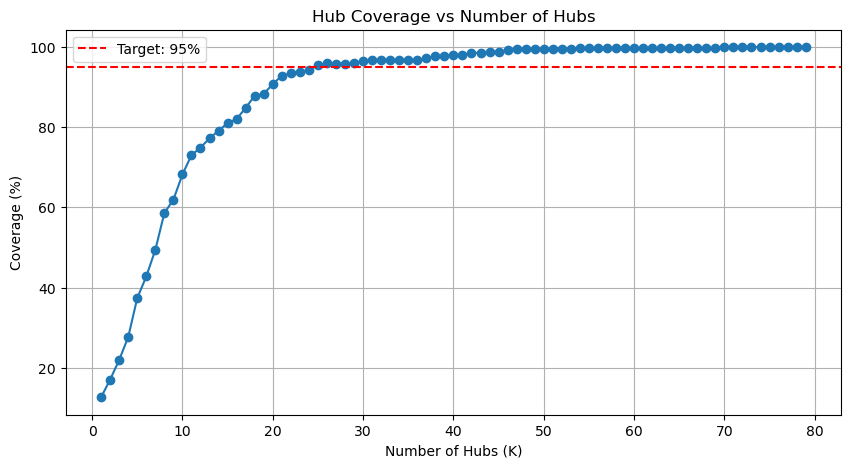

In [8]:
coords_all = df_orders[['order_latitude', 'order_longitude']].dropna().to_numpy()

hub_locator = HubLocations(
    coordinates=coords_all,
    k_range=range(1, 80),
    max_distance_km=4,
    seed=1
)

df_coverage = hub_locator.evaluate_coverage()
optimal_k, unique_hubs = hub_locator.select_optimal_hubs(target_coverage=TARGET_COVERAGE)
print(f"Optimal number of hubs for {TARGET_COVERAGE}% coverage: {optimal_k}")
hub_locator.plot_coverage_curve(target_coverage=TARGET_COVERAGE)


# Applying Nearest Neighbor Allocation with Fixed routing and moving window strategies

In [9]:
hubs_with_both_routes = prepare_orders_with_best_hub_and_routes(
    df_orders = df_orders,
    df_hubs = unique_hubs,
    max_adensing_minutes = max_adensing_minutes,
    max_orders_per_route = max_orders_per_route,
    max_weight_per_route = max_weight_per_route
)

# Allocating based on open routes

In [10]:
df = hubs_with_both_routes.sort_values(by=['ordered_at_brt']).drop_duplicates(subset=['order_id'])[['order_id','order_latitude','order_longitude','ordered_at_brt','order_weight','sla_max_delivery_time_brt']].drop_duplicates(subset=['order_id']).sort_values(by=['ordered_at_brt']).reset_index(drop=True)
allocation_result_open_routes, audit_trail = allocate_orders_open_routes_with_audit_proximity_priority(
    df,
    unique_hubs,
    CONFIG,
    use_dynamic_adensing=False,
)

allocation_result_open_routes_dynamic, audit_trail_dynamic = allocate_orders_open_routes_with_audit_proximity_priority(
    df,
    unique_hubs,
    CONFIG,
    use_dynamic_adensing=True,
)

allocation_result_open_routes_dynamic_empirical_data, audit_trail_dynamic_empirical_data = allocate_orders_open_routes_with_audit_proximity_priority(
    df,
    unique_hubs,
    CONFIG,
    use_dynamic_adensing=True,
    use_empirical_speed = True,
    speed_sampler=speed_sampler
)

# Routing

In [14]:
route_generator = RouteGenerator()

fact_route_order_nn_zero_routing = route_generator.generate_fact_table(
    df_routes=hubs_with_both_routes,
    route_id_col='route_id_nn_zero_routing',
    hub_id_col='hub_id'
)

fact_route_order_nn_fixed_window = route_generator.generate_fact_table(
    df_routes=hubs_with_both_routes,
    route_id_col='route_id_nn_fixed_window',
    hub_id_col='hub_id'
)

fact_route_order_nn_moving_window = route_generator.generate_fact_table(
    df_routes=hubs_with_both_routes,
    route_id_col='route_id_nn_moving_window',
    hub_id_col='hub_id'
)

fact_route_order_open_routes = route_generator.generate_fact_table(
    df_routes=allocation_result_open_routes.rename(columns={'route_id': 'route_id_open_routes'}),
    route_id_col='route_id_open_routes',
    hub_id_col='hub_id'
)

fact_route_order_open_routes_dynamic = route_generator.generate_fact_table(
    df_routes=allocation_result_open_routes_dynamic.rename(columns={'route_id': 'route_id_open_routes_dynamic'}),
    route_id_col='route_id_open_routes_dynamic',
    hub_id_col='hub_id'
)

fact_route_order_open_routes_dynamic_empirical_data = route_generator.generate_fact_table(
    df_routes=allocation_result_open_routes_dynamic_empirical_data.rename(columns={'route_id': 'route_id_open_routes_dynamic_empirical_data'}),
    route_id_col='route_id_open_routes_dynamic_empirical_data',
    hub_id_col='hub_id'
)

# Getting Comparison between Models

In [15]:
# Selecting only necessary columns
base_df=hubs_with_both_routes[['order_id',
                               'order_longitude',
                              'order_latitude',
                              'ordered_at_brt',
                              'sla_hours',
                              'order_weight',
                              'sla_max_delivery_time_brt']]

# Models Dictionary
models = {
    'nn_zero_routing': {
        'fact': fact_route_order_nn_zero_routing,
        'route_col': 'route_id_nn_zero_routing'
    },    
    'nn_fixed_window': {
        'fact': fact_route_order_nn_fixed_window,
        'route_col': 'route_id_nn_fixed_window'
    },
    'nn_moving_window': {
        'fact': fact_route_order_nn_moving_window,
        'route_col': 'route_id_nn_moving_window'
    },
    'open_routes': {
        'fact': fact_route_order_open_routes,
        'route_col': 'route_id_open_routes'
    },
    'open_routes_dynamic': {
        'fact': fact_route_order_open_routes_dynamic,
        'route_col': 'route_id_open_routes_dynamic'
    },
    'open_routes_dynamic_empirical_data': {
        'fact': fact_route_order_open_routes_dynamic_empirical_data,
        'route_col': 'route_id_open_routes_dynamic_empirical_data'
    },
   
}

evaluator = ModelEvaluator(
    models=models,
    config=CONFIG,
    seed=seed,
    use_empirical_dispatch_time=False,
    use_empirical_speed=False
)

evaluator_both = ModelEvaluator(
    models=models,
    config=CONFIG,
    seed=1,
    empirical_df=delivery_center_data,
    use_empirical_dispatch_time=True,
    use_empirical_speed=True,
    bin_size_km=0.5,
    overflow_quantile=0.95
)
evaluator.prepare_inputs()

df_full = evaluator.merge_outputs(base_df)

df_full_with_features = evaluator.compute_features(df_full)

summary_df = evaluator.summarize(df_full_with_features)

evaluator_both.prepare_inputs()

df_full_both = evaluator_both.merge_outputs(base_df)

df_full_both_with_features = evaluator_both.compute_features(df_full_both)

summary_df_both = evaluator_both.summarize(df_full_both_with_features)

C:\Users\EduardoMontez\AppData\Local\Temp\ipykernel_31824\996966853.py:1176: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for bin_label, group in self.empirical_df.groupby('distance_bin_km')


In [28]:
summary_df.to_excel('simulado.xlsx',index=False)

In [29]:
summary_df_both.to_excel('empirico.xlsx',index=False)

In [24]:
summary_df.to_csv('results_simulated_data.csv',index=False)


In [26]:
summary_df

,model,orders,routes,grouped_orders,routing_rate_%,adjusted_distance_km,total_cost,sla_achieved_%,avg_fulfill_time_min,avg_adensing_time_min,avg_dispatch_time_min,avg_route_time_min
0,nn_zero_routing,1000,1000,0,0.0,3092.388031,8406.246236,99.8,29.439318,0.000000,17.038812,12.400505
1,nn_fixed_window,1000,748,463,46.3,2958.476619,7309.768112,95.4,45.412037,15.116000,17.569831,12.726206
2,nn_moving_window,1000,630,649,64.9,2857.320266,6752.118306,83.0,55.546132,24.750458,18.009926,12.785748
3,open_routes,1000,540,767,76.7,3075.767940,6666.733131,83.2,55.607275,23.154864,18.251822,14.200589
4,open_routes_dynamic,1000,585,719,71.9,2995.000639,6742.150735,99.4,61.391081,29.666438,18.101511,13.623132
5,open_routes_dynamic_empirical_data,1000,605,695,69.5,3002.192247,6825.221084,99.2,59.179077,27.643755,18.013218,13.522105


In [89]:
unique_hubs['icon']='home'

In [90]:
unique_hubs.to_csv('hubs_simula.csv')

In [91]:
df_orders.to_csv('pedidos_simula.csv')

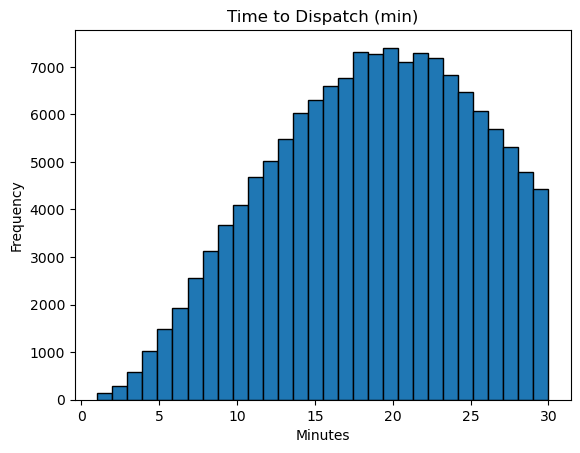

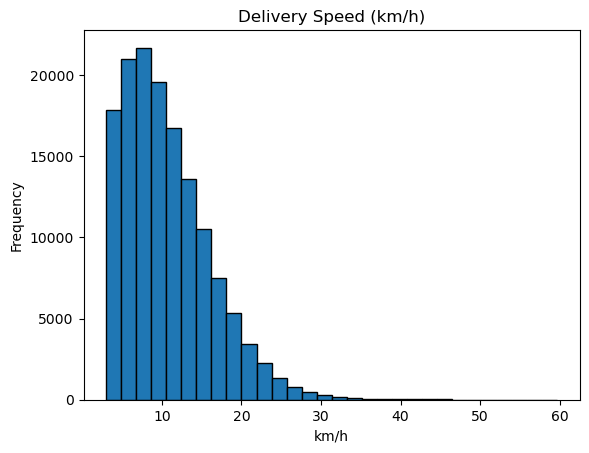

In [18]:
import matplotlib.pyplot as plt

plt.hist(delivery_center_data['time_to_dispatch'], bins=30, edgecolor='k')
plt.title('Time to Dispatch (min)')
plt.xlabel('Minutes')
plt.ylabel('Frequency')
plt.show()

plt.hist(delivery_center_data['km_hour'], bins=30, edgecolor='k')
plt.title('Delivery Speed (km/h)')
plt.xlabel('km/h')
plt.ylabel('Frequency')
plt.show()


In [72]:

overflow_threshold = delivery_center_data['delivery_distance_meters'].quantile(0.95)
# Gera bin edges de 500 em 500 até o threshold
bin_edges = np.arange(0, overflow_threshold + 500, 500)
labels = [f'{int(a)}–{int(b-1)}m' for a, b in zip(bin_edges[:-1], bin_edges[1:])] + ['overflow']

# Aplica com bin final para os 5% mais altos
delivery_center_data['distance_bin_500m'] = pd.cut(
    delivery_center_data['delivery_distance_meters'],
    bins=list(bin_edges) + [delivery_center_data['delivery_distance_meters'].max() + 1],
    include_lowest=True,
    right=False,
    labels=labels
)

C:\Users\EduardoMontez\AppData\Local\Temp\ipykernel_31824\2431250494.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  delivery_center_data.groupby('distance_bin_km')['km_hour'].mean().plot(kind='bar', figsize=(12, 5), title='Avearge speed (km/hour) by distance bin (0.5km)')


<Axes: title={'center': 'Avearge speed (km/hour) by distance bin (0.5km)'}, xlabel='distance_bin_km'>

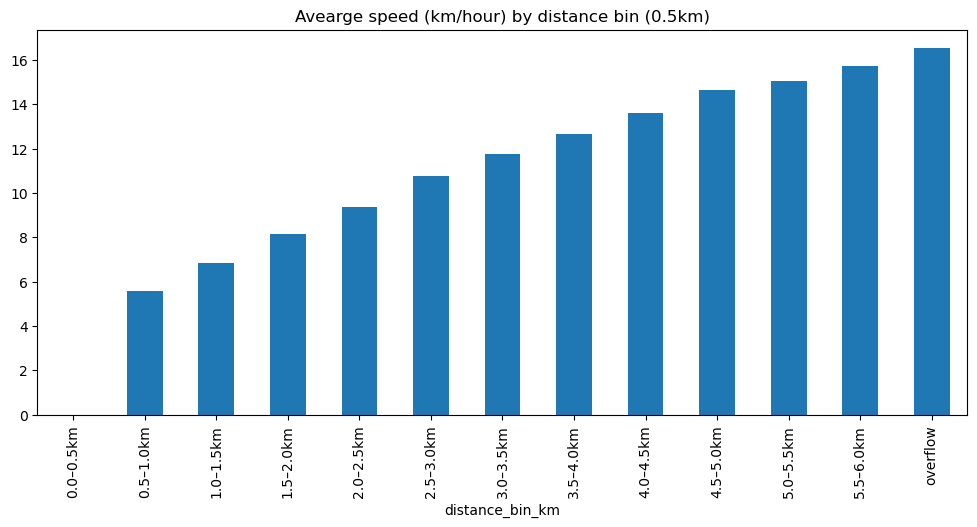

In [22]:
delivery_center_data.groupby('distance_bin_km')['km_hour'].mean().plot(kind='bar', figsize=(12, 5), title='Avearge speed (km/hour) by distance bin (0.5km)')
